In [1]:
import pandas as pd
import numpy as np

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

from pathlib import Path
data = Path('/home/py/groundwater/data/bow_valley/gown_features.csv')

In [63]:
df = pd.read_csv(data)
df

,well,group,primary_driver,ann_amp_m,recession_tau_d,ccf_lag_d,hyst_h,coh_submonthly,coh_annual,aquifer,aquifer_type,expert_family
0,760,Canmore,brac_e,2.589,101.9,2,-0.214,0.445,0.956,Calgary Valley,Unconfined,A_river_unconfined
1,759,Canmore,brac_e,2.699,68.5,2,-0.137,0.334,0.961,Calgary Valley,Confined,B_deep_confined
2,764,Canmore,brac_e,3.802,68.4,18,-0.475,0.278,0.951,Surficial,---,C_till_mtnfront
3,364,Canmore,brac_e,0.415,150.4,1,-0.052,0.340,0.890,Buried Valley,Confined,F_damped_confined
4,931,Marmot,krns,3.895,92.4,4,-0.098,0.276,0.968,Surficial,Unconfined,A_river_unconfined
5,301,Marmot,krns,2.035,78.8,-2,0.182,0.275,0.968,Rocky Mountain,---,E_shallow_leads
6,303,Marmot,krns,5.946,65.4,2,-0.157,0.269,0.953,Rocky Mountain,---,D_lowstorage_bedrock
7,386,Marmot,krns,0.983,83.2,2,-0.134,0.302,0.955,Surficial,---,E_shallow_leads
8,305,Marmot,krns,7.768,83.1,-1,0.053,0.257,0.944,Fernie,---,D_lowstorage_bedrock


In [56]:
# FEATURES = ["ann_amp_m","recession_tau_d","ccf_lag_d","hyst_h","coh_submonthly","coh_annual"]
# FEATURES = ["ann_amp_m","ccf_lag_d","hyst_h","coh_submonthly","coh_annual"]
FEATURES = ["ann_amp_m","ccf_lag_d","coh_submonthly","recession_tau_d"]

In [57]:
X = df[FEATURES].to_numpy(float)
X_z = (X - X.mean(0)) / X.std(0, ddof=1)

In [58]:
X_z

array([[-0.32471686, -0.18955004,  2.32326802,  0.52906747],
       [-0.27765645, -0.18955004,  0.43478572, -0.74323398],
       [ 0.19423117,  2.5399706 , -0.51796211, -0.74704327],
       [-1.25480179, -0.36014508,  0.53686584,  2.37657108],
       [ 0.23401861,  0.15164004, -0.55198882,  0.16718532],
       [-0.56173022, -0.87193021, -0.56900218, -0.35087755],
       [ 1.11148143, -0.18955004, -0.6710823 , -0.86132184],
       [-1.01179892, -0.18955004, -0.10964162, -0.18326897],
       [ 1.89097303, -0.70133517, -0.87524255, -0.18707826]])

In [59]:
labels = [f"{w} [{f.split('_')[0]}/{a}]" for w, f, a in zip(df.well, df.expert_family, df.aquifer_type)]

In [60]:
method = "ward"

In [61]:
Z = linkage(X_z, method=method)

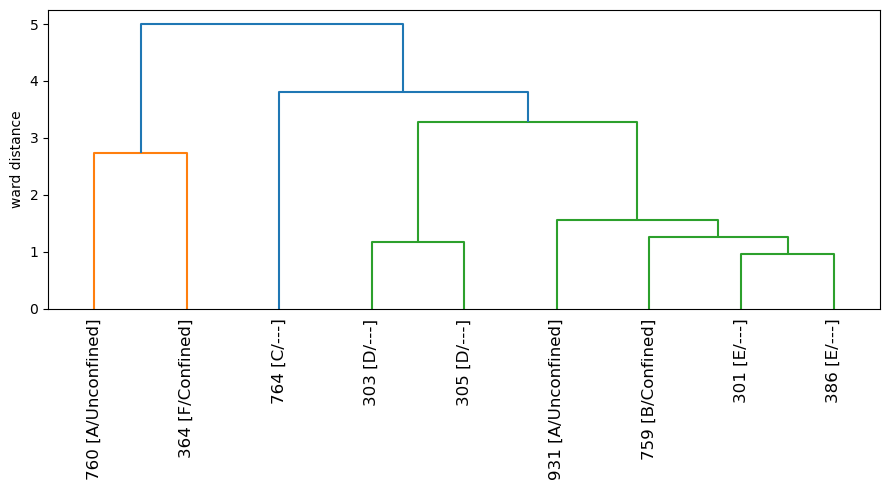

In [62]:
plt.figure(figsize=(9, 5))
dendrogram(Z, labels=labels, leaf_rotation=90)
plt.ylabel(f"{method} distance")
plt.tight_layout()

In [31]:
for k in (3, 4, 5):
    df[f"cluster_k{k}"] = fcluster(Z, k, criterion="maxclust")
print(df[["well","expert_family","aquifer_type","cluster_k3","cluster_k4","cluster_k5"]].to_string(index=False))

 well        expert_family aquifer_type  cluster_k3  cluster_k4  cluster_k5
  760   A_river_unconfined   Unconfined           1           1           2
  759      B_deep_confined     Confined           1           1           1
  764      C_till_mtnfront          ---           2           3           4
  364    F_damped_confined     Confined           3           4           5
  931   A_river_unconfined   Unconfined           1           1           1
  301      E_shallow_leads          ---           1           1           1
  303 D_lowstorage_bedrock          ---           2           2           3
  386      E_shallow_leads          ---           1           1           1
  305 D_lowstorage_bedrock          ---           2           2           3


In [32]:
print(df[FEATURES].corr().round(2))

                ann_amp_m  ccf_lag_d  coh_submonthly  coh_annual
ann_amp_m            1.00       0.03           -0.47        0.27
ccf_lag_d            0.03       1.00           -0.11        0.06
coh_submonthly      -0.47      -0.11            1.00       -0.17
coh_annual           0.27       0.06           -0.17        1.00
